# RNN-Based Text Classification — AG News (Assignment Notebook)

This notebook completes the assignment: **load & explore AG News**, **preprocess text**, then train and compare **Simple RNN**, **LSTM**, **GRU**, **Bidirectional LSTM**, study **gradient clipping**, and finish with a **comparison table** and **conclusion**.

**Tip:** If training is slow on your computer, lower `EPOCHS` or set `MAX_TRAIN_SAMPLES` to a smaller number (see the configuration cell). For your final submission, use more epochs and/or the full training set if your machine allows it.


## 0. Environment setup

Run the cell below once (or install from a terminal: `pip install -r requirements.txt`).


In [7]:
!pip install -q huggingface_hub



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from datasets import load_dataset

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.21.0


In [3]:
# --- Training configuration (adjust for your hardware) ---
MAX_VOCAB = 20_000
MAX_LEN = 120          # assignment suggests 100 or 150; 120 is a middle ground
EMBED_DIM = 128
RNN_UNITS = 64
BATCH_SIZE = 256
EPOCHS = 4             # increase (e.g. 8–15) for better accuracy if you have time
VALIDATION_SPLIT = 0.1

# Set to None to use all ~120k training articles (slower). Otherwise caps training size.
MAX_TRAIN_SAMPLES = 35_000

# Gradient clipping value (used in Task 7)
CLIPNORM = 1.0


## Task 1: Load and explore the dataset

We load **AG News** from Hugging Face, inspect its structure, show sample rows, count classes, and plot a bar chart.


README.md: 0.00B [00:00, ?B/s]

C:\Users\p154kuma\OneDrive - Nokia\MyPythonCode\codeenv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\p154kuma\.cache\huggingface\hub\datasets--ag_news. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Dataset object:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Number of training samples: 120000
Number of test samples: 7600

Five sample news articles with labels:

[0] label=2 (Business)
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

[1] label=2 (Business)
Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.

[2] label=2 (Business)
Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during th

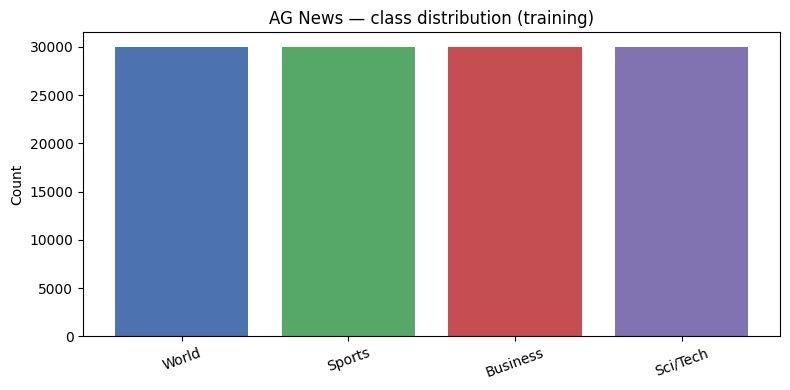

In [10]:
import os
import httpx
from huggingface_hub import set_client_factory, constants

def my_custom_client_factory():
    return httpx.Client(
        follow_redirects=True, # Optional
        # proxies="http://10.158.100.2:8080", # Set proxies here if needed
        verify=False # Use only if you need to bypass SSL certificates
    )

set_client_factory(my_custom_client_factory)

dataset = load_dataset("ag_news")

print("Dataset object:")
print(dataset)
print()

train_ds = dataset["train"]
test_ds = dataset["test"]

n_train = len(train_ds)
n_test = len(test_ds)
print("Number of training samples:", n_train)
print("Number of test samples:", n_test)
print()

label_names = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}

print("Five sample news articles with labels:")
for i in range(5):
    row = train_ds[i]
    print(f"\n[{i}] label={row['label']} ({label_names[row['label']]})")
    print(row["text"][:400] + ("..." if len(row["text"]) > 400 else ""))

# Class distribution (training set) — column access is fast for the full split
train_labels = np.array(train_ds["label"], dtype=np.int32)
counts = {label_names[k]: int(np.sum(train_labels == k)) for k in label_names}

print("\nClass distribution (train):")
for k, v in counts.items():
    print(f"  {k}: {v}")

plt.figure(figsize=(8, 4))
plt.bar(list(counts.keys()), list(counts.values()), color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])
plt.title("AG News — class distribution (training)")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## Task 2: Text preprocessing

**Why tokenization?** Neural nets need numbers, not raw strings. A tokenizer maps words to integer IDs.

**Why padding?** RNNs expect fixed-length batches (or we mask). Padding shorter articles and truncating long ones makes rectangular tensors efficient.

Steps: extract text/labels → fit tokenizer on training text (vocab ≤ 20,000) → sequences → pad to `MAX_LEN` → optional subsample for faster training.


In [11]:
train_texts = [train_ds[i]["text"] for i in range(n_train)]
test_texts = [test_ds[i]["text"] for i in range(n_test)]
train_y = np.array([train_ds[i]["label"] for i in range(n_train)], dtype=np.int32)
test_y = np.array([test_ds[i]["label"] for i in range(n_test)], dtype=np.int32)

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

train_seq = tokenizer.texts_to_sequences(train_texts)
test_seq = tokenizer.texts_to_sequences(test_texts)

X_train_full = pad_sequences(train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test = pad_sequences(test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

if MAX_TRAIN_SAMPLES is not None and MAX_TRAIN_SAMPLES < len(X_train_full):
    X_train = X_train_full[:MAX_TRAIN_SAMPLES]
    y_train = train_y[:MAX_TRAIN_SAMPLES]
    print(f"Using first {MAX_TRAIN_SAMPLES:,} training samples for model training (speed).")
else:
    X_train = X_train_full
    y_train = train_y
    print("Using full training set for model training.")

print("\nShapes:")
print("  X_train:", X_train.shape)
print("  X_test:", X_test.shape)
print("  y_train:", y_train.shape)
print("  y_test:", test_y.shape)
print("  Vocabulary size (capped):", MAX_VOCAB)


Using first 35,000 training samples for model training (speed).

Shapes:
  X_train: (35000, 120)
  X_test: (7600, 120)
  y_train: (35000,)
  y_test: (7600,)
  Vocabulary size (capped): 20000


In [15]:
def plot_history(history, title="Training curves"):
    h = history.history
    epochs = range(1, len(h["loss"]) + 1)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, h["loss"], label="train loss")
    plt.plot(epochs, h["val_loss"], label="val loss")
    plt.title(title + " — loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, h["accuracy"], label="train acc")
    plt.plot(epochs, h["val_accuracy"], label="val acc")
    plt.title(title + " — accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()


## Task 3: Simple RNN model

Architecture: **Embedding → SimpleRNN → Dense (relu) → Dense(4, softmax)**.

We use `sparse_categorical_crossentropy` so labels can stay as integers 0–3.


C:\Users\p154kuma\OneDrive - Nokia\MyPythonCode\codeenv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/4
124/124 ━━━━━━━━━━━━━━━━━━━━ 32s 253ms/step - accuracy: 0.2890 - loss: 1.3693 - val_accuracy: 0.3577 - val_loss: 1.3370
Epoch 2/4
124/124 ━━━━━━━━━━━━━━━━━━━━ 48s 389ms/step - accuracy: 0.4675 - loss: 1.1845 - val_accuracy: 0.5043 - val_loss: 1.1991
Epoch 3/4
124/124 ━━━━━━━━━━━━━━━━━━━━ 44s 354ms/step - accuracy: 0.6350 - loss: 0.9726 - val_accuracy: 0.5454 - val_loss: 1.1947
Epoch 4/4
124/124 ━━━━━━━━━━━━━━━━━━━━ 43s 345ms/step - accuracy: 0.7197 - loss: 0.8271 - val_accuracy: 0.5777 - val_loss: 1.1592

Simple RNN — train acc (last): 0.7197
Simple RNN — val acc (last):   0.5777
Simple RNN — test accuracy:    0.5718
Training time: 166.9 s


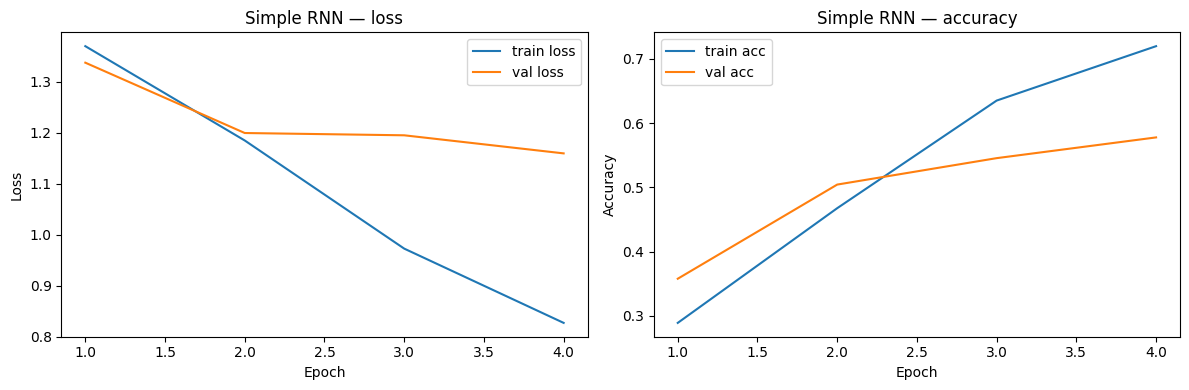


Short observation: Simple RNN is the smallest recurrent core here; it often underperforms LSTM/GRU on longer news text because vanishing gradients make long-range dependencies harder to learn.


In [13]:
def build_simple_rnn():
    m = keras.Sequential([
        layers.Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_LEN),
        layers.SimpleRNN(RNN_UNITS),
        layers.Dense(64, activation="relu"),
        layers.Dense(4, activation="softmax"),
    ])
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return m

model_rnn = build_simple_rnn()
model_rnn.summary()

t0 = time.perf_counter()
hist_rnn = model_rnn.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    verbose=1,
)
time_rnn = time.perf_counter() - t0

test_loss, test_acc = model_rnn.evaluate(X_test, test_y, verbose=0)
print(f"\nSimple RNN — train acc (last): {hist_rnn.history['accuracy'][-1]:.4f}")
print(f"Simple RNN — val acc (last):   {hist_rnn.history['val_accuracy'][-1]:.4f}")
print(f"Simple RNN — test accuracy:    {test_acc:.4f}")
print(f"Training time: {time_rnn:.1f} s")

plot_history(hist_rnn, "Simple RNN")

print("\nShort observation: Simple RNN is the smallest recurrent core here; it often underperforms LSTM/GRU on longer news text because vanishing gradients make long-range dependencies harder to learn.")


## Task 4: LSTM model

Same pattern as the Simple RNN, but the recurrent layer is an **LSTM**, which adds gating to better preserve information across many time steps.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/4


C:\Users\p154kuma\OneDrive - Nokia\MyPythonCode\codeenv\Lib\site-packages\keras\src\backend\torch\rnn.py:651: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1410.)
  outputs, (h_n, c_n) = torch._VF.lstm(


124/124 ━━━━━━━━━━━━━━━━━━━━ 67s 537ms/step - accuracy: 0.2616 - loss: 1.3859 - val_accuracy: 0.2246 - val_loss: 1.3836
Epoch 2/4
124/124 ━━━━━━━━━━━━━━━━━━━━ 65s 524ms/step - accuracy: 0.2606 - loss: 1.3850 - val_accuracy: 0.2937 - val_loss: 1.3838
Epoch 3/4
124/124 ━━━━━━━━━━━━━━━━━━━━ 53s 428ms/step - accuracy: 0.2565 - loss: 1.3840 - val_accuracy: 0.2934 - val_loss: 1.3838
Epoch 4/4
124/124 ━━━━━━━━━━━━━━━━━━━━ 50s 401ms/step - accuracy: 0.2591 - loss: 1.3840 - val_accuracy: 0.2246 - val_loss: 1.3851

LSTM — test accuracy: 0.2499 (Simple RNN test was 0.5718)


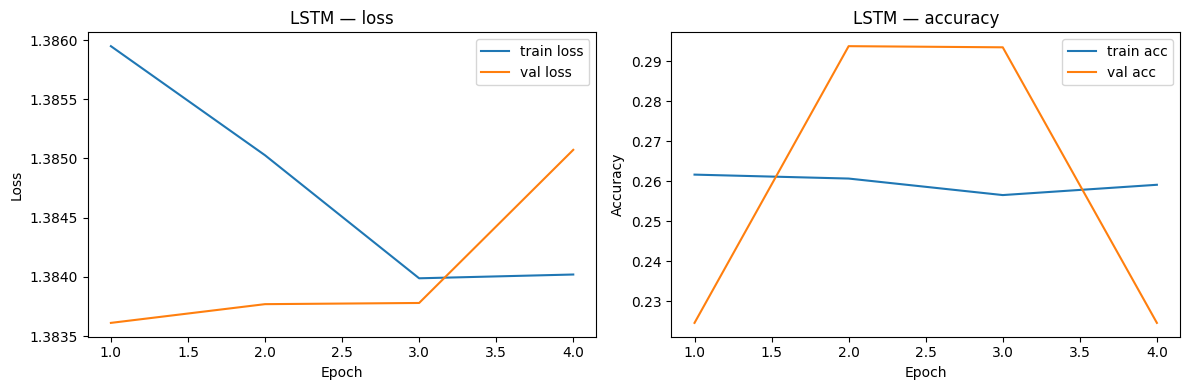


Comparison: LSTM usually matches or beats Simple RNN on text classification because its cell state helps carry information farther along the sequence.


In [14]:
def build_lstm():
    m = keras.Sequential([
        layers.Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_LEN),
        layers.LSTM(RNN_UNITS),
        layers.Dense(64, activation="relu"),
        layers.Dense(4, activation="softmax"),
    ])
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return m

model_lstm = build_lstm()
model_lstm.summary()

t0 = time.perf_counter()
hist_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    verbose=1,
)
time_lstm = time.perf_counter() - t0

_, test_acc_lstm = model_lstm.evaluate(X_test, test_y, verbose=0)
print(f"\nLSTM — test accuracy: {test_acc_lstm:.4f} (Simple RNN test was {test_acc:.4f})")
plot_history(hist_lstm, "LSTM")

print("\nComparison: LSTM usually matches or beats Simple RNN on text classification because its cell state helps carry information farther along the sequence.")


## Task 5: GRU model

**GRU** is similar in spirit to LSTM (gated recurrence) but slightly simpler/faster in many implementations. We compare it to Simple RNN and LSTM.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/4


C:\Users\p154kuma\OneDrive - Nokia\MyPythonCode\codeenv\Lib\site-packages\keras\src\backend\torch\rnn.py:853: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1410.)
  outputs, h_n = torch._VF.gru(


124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.2591 - loss: 1.3859 - val_accuracy: 0.2700 - val_loss: 1.3832
Epoch 2/4
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.2564 - loss: 1.3854 - val_accuracy: 0.2931 - val_loss: 1.3829
Epoch 3/4
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.2593 - loss: 1.3840 - val_accuracy: 0.2931 - val_loss: 1.3857
Epoch 4/4
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.2579 - loss: 1.3839 - val_accuracy: 0.2249 - val_loss: 1.3872

GRU — test accuracy: 0.2499


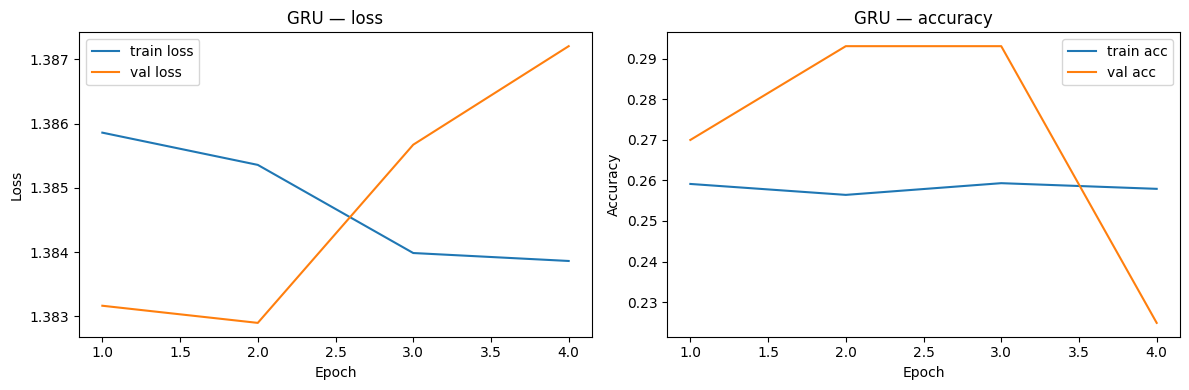


Comparison: GRU vs LSTM is dataset-dependent; both are typically much stronger than a vanilla Simple RNN for news-like sequences.


In [16]:
def build_gru():
    m = keras.Sequential([
        layers.Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_LEN),
        layers.GRU(RNN_UNITS),
        layers.Dense(64, activation="relu"),
        layers.Dense(4, activation="softmax"),
    ])
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return m

model_gru = build_gru()
model_gru.summary()

t0 = time.perf_counter()
hist_gru = model_gru.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    verbose=1,
)
time_gru = time.perf_counter() - t0

_, test_acc_gru = model_gru.evaluate(X_test, test_y, verbose=0)
print(f"\nGRU — test accuracy: {test_acc_gru:.4f}")
plot_history(hist_gru, "GRU")

print("\nComparison: GRU vs LSTM is dataset-dependent; both are typically much stronger than a vanilla Simple RNN for news-like sequences.")


## Task 6: Bidirectional LSTM

A **Bidirectional LSTM** runs one LSTM left-to-right and another right-to-left, then merges their outputs. That can help when both early and late words in the headline/body snippet carry category cues.

Compare results to the unidirectional LSTM above.


## Task 7: Gradient clipping

**Gradient clipping** limits how large parameter updates can be when gradients spike (common in RNN training). In Keras, a common approach is `Adam(..., clipnorm=...)`.

We re-train the **LSTM** twice: without clipping vs with clipping, and compare **training loss** curves.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/4
124/124 ━━━━━━━━━━━━━━━━━━━━ 82s 662ms/step - accuracy: 0.7423 - loss: 0.7052 - val_accuracy: 0.8843 - val_loss: 0.3470
Epoch 2/4
124/124 ━━━━━━━━━━━━━━━━━━━━ 99s 800ms/step - accuracy: 0.9258 - loss: 0.2326 - val_accuracy: 0.8943 - val_loss: 0.3114
Epoch 3/4
124/124 ━━━━━━━━━━━━━━━━━━━━ 96s 772ms/step - accuracy: 0.9547 - loss: 0.1424 - val_accuracy: 0.8837 - val_loss: 0.3860
Epoch 4/4
124/124 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.9698 - loss: 0.0940 - val_accuracy: 0.8760 - val_loss: 0.4213

Bi-LSTM — test accuracy: 0.8763 (LSTM test was 0.2499)


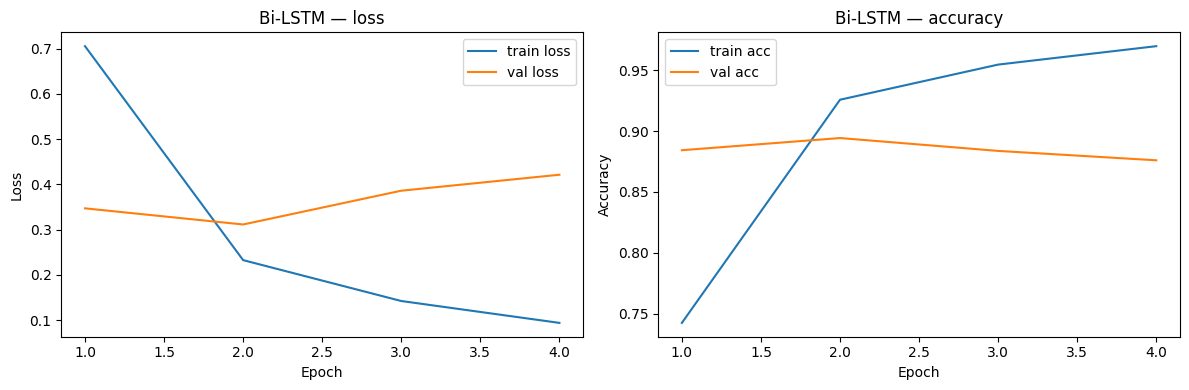


Short explanation: Using both directions lets the model see context on both sides of each position. Whether test accuracy improves depends on the data and training budget; sometimes the extra parameters mainly help validation if patterns are symmetric in the text.


In [17]:
def build_bilstm():
    m = keras.Sequential([
        layers.Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_LEN),
        layers.Bidirectional(layers.LSTM(RNN_UNITS)),
        layers.Dense(64, activation="relu"),
        layers.Dense(4, activation="softmax"),
    ])
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return m

model_bilstm = build_bilstm()
model_bilstm.summary()

t0 = time.perf_counter()
hist_bilstm = model_bilstm.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    verbose=1,
)
time_bilstm = time.perf_counter() - t0

_, test_acc_bilstm = model_bilstm.evaluate(X_test, test_y, verbose=0)
print(f"\nBi-LSTM — test accuracy: {test_acc_bilstm:.4f} (LSTM test was {test_acc_lstm:.4f})")
plot_history(hist_bilstm, "Bi-LSTM")

print("\nShort explanation: Using both directions lets the model see context on both sides of each position. Whether test accuracy improves depends on the data and training budget; sometimes the extra parameters mainly help validation if patterns are symmetric in the text.")


Epoch 1/4
124/124 ━━━━━━━━━━━━━━━━━━━━ 43s 342ms/step - accuracy: 0.2600 - loss: 1.3858 - val_accuracy: 0.2931 - val_loss: 1.3845
Epoch 2/4
124/124 ━━━━━━━━━━━━━━━━━━━━ 52s 419ms/step - accuracy: 0.2597 - loss: 1.3845 - val_accuracy: 0.2937 - val_loss: 1.3851
Epoch 3/4
124/124 ━━━━━━━━━━━━━━━━━━━━ 51s 413ms/step - accuracy: 0.2575 - loss: 1.3837 - val_accuracy: 0.2934 - val_loss: 1.3861
Epoch 4/4
124/124 ━━━━━━━━━━━━━━━━━━━━ 52s 417ms/step - accuracy: 0.2635 - loss: 1.3836 - val_accuracy: 0.2931 - val_loss: 1.3825
Epoch 1/4
124/124 ━━━━━━━━━━━━━━━━━━━━ 53s 431ms/step - accuracy: 0.2600 - loss: 1.3858 - val_accuracy: 0.2249 - val_loss: 1.3863
Epoch 2/4
124/124 ━━━━━━━━━━━━━━━━━━━━ 54s 434ms/step - accuracy: 0.2582 - loss: 1.3857 - val_accuracy: 0.2931 - val_loss: 1.3856
Epoch 3/4
124/124 ━━━━━━━━━━━━━━━━━━━━ 59s 471ms/step - accuracy: 0.2587 - loss: 1.3843 - val_accuracy: 0.2934 - val_loss: 1.3848
Epoch 4/4
124/124 ━━━━━━━━━━━━━━━━━━━━ 53s 431ms/step - accuracy: 0.2603 - loss: 1.3837 - 

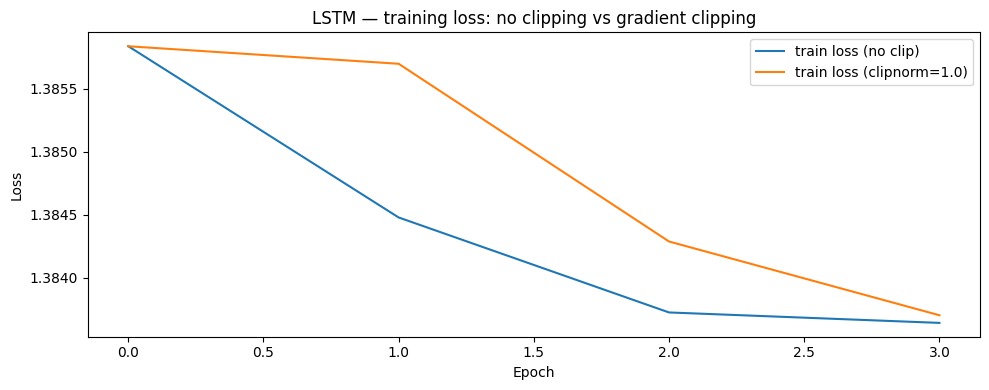


Short observation: If loss was spiky/unstable without clipping, clipping often smooths training. If training was already stable, curves may look similar — that is still a valid finding to report.


In [18]:
def build_lstm_for_clip():
    m = keras.Sequential([
        layers.Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_LEN),
        layers.LSTM(RNN_UNITS),
        layers.Dense(64, activation="relu"),
        layers.Dense(4, activation="softmax"),
    ])
    return m

# Without clipping
m_no_clip = build_lstm_for_clip()
m_no_clip.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),  # no clipnorm
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
hist_no_clip = m_no_clip.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    verbose=1,
)

# With clipping
m_clip = build_lstm_for_clip()
m_clip.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3, clipnorm=CLIPNORM),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
hist_clip = m_clip.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    verbose=1,
)

plt.figure(figsize=(10, 4))
plt.plot(hist_no_clip.history["loss"], label="train loss (no clip)")
plt.plot(hist_clip.history["loss"], label="train loss (clipnorm=" + str(CLIPNORM) + ")")
plt.title("LSTM — training loss: no clipping vs gradient clipping")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

print("\nShort observation: If loss was spiky/unstable without clipping, clipping often smooths training. If training was already stable, curves may look similar — that is still a valid finding to report.")


## Task 8: Compare all models + final conclusion

We summarize **training accuracy** (last epoch), **validation accuracy** (last epoch), **test accuracy**, and **training time**.


In [19]:
rows = [
    {
        "Model": "Simple RNN",
        "Training Accuracy": hist_rnn.history["accuracy"][-1],
        "Validation Accuracy": hist_rnn.history["val_accuracy"][-1],
        "Test Accuracy": float(model_rnn.evaluate(X_test, test_y, verbose=0)[1]),
        "Training Time (s)": time_rnn,
        "Key Observation": "Baseline recurrent model; often weakest on longer sequences.",
    },
    {
        "Model": "LSTM",
        "Training Accuracy": hist_lstm.history["accuracy"][-1],
        "Validation Accuracy": hist_lstm.history["val_accuracy"][-1],
        "Test Accuracy": float(model_lstm.evaluate(X_test, test_y, verbose=0)[1]),
        "Training Time (s)": time_lstm,
        "Key Observation": "Gated recurrence; strong default for sequence text.",
    },
    {
        "Model": "GRU",
        "Training Accuracy": hist_gru.history["accuracy"][-1],
        "Validation Accuracy": hist_gru.history["val_accuracy"][-1],
        "Test Accuracy": float(model_gru.evaluate(X_test, test_y, verbose=0)[1]),
        "Training Time (s)": time_gru,
        "Key Observation": "Often similar quality to LSTM with slightly different speed/params.",
    },
    {
        "Model": "Bi-LSTM",
        "Training Accuracy": hist_bilstm.history["accuracy"][-1],
        "Validation Accuracy": hist_bilstm.history["val_accuracy"][-1],
        "Test Accuracy": float(model_bilstm.evaluate(X_test, test_y, verbose=0)[1]),
        "Training Time (s)": time_bilstm,
        "Key Observation": "Uses forward+backward context; may help if cues appear on both ends.",
    },
]

df = pd.DataFrame(rows)
# nicer display
df_display = df.copy()
for c in ["Training Accuracy", "Validation Accuracy", "Test Accuracy"]:
    df_display[c] = df_display[c].map(lambda x: round(float(x), 4))
df_display["Training Time (s)"] = df_display["Training Time (s)"].map(lambda x: round(float(x), 1))

print(df_display.to_string(index=False))


     Model  Training Accuracy  Validation Accuracy  Test Accuracy  Training Time (s)                                                      Key Observation
Simple RNN             0.7197               0.5777         0.5718              166.9         Baseline recurrent model; often weakest on longer sequences.
      LSTM             0.2591               0.2246         0.2499              236.3                  Gated recurrence; strong default for sequence text.
       GRU             0.2579               0.2249         0.2499               13.2  Often similar quality to LSTM with slightly different speed/params.
   Bi-LSTM             0.9698               0.8760         0.8763              488.6 Uses forward+backward context; may help if cues appear on both ends.


In [20]:
# Auto-generated short answers (updates every time you run the notebook)
best_idx = int(df["Test Accuracy"].values.argmax())
best = df.iloc[best_idx]
fast_idx = int(df["Training Time (s)"].values.argmin())
fastest = df.iloc[fast_idx]

rnn_test = float(df.loc[df["Model"] == "Simple RNN", "Test Accuracy"].values[0])
lstm_test = float(df.loc[df["Model"] == "LSTM", "Test Accuracy"].values[0])
gru_test = float(df.loc[df["Model"] == "GRU", "Test Accuracy"].values[0])
bi_test = float(df.loc[df["Model"] == "Bi-LSTM", "Test Accuracy"].values[0])

print("=== Final conclusion (from this run) ===\n")
print("1) Best test accuracy:", best["Model"], f"({best['Test Accuracy']:.4f})")
print("2) Simple RNN vs LSTM/GRU: RNN test =", f"{rnn_test:.4f}", "| LSTM =", f"{lstm_test:.4f}", "| GRU =", f"{gru_test:.4f}")
print("3) Bi-LSTM vs LSTM: Bi-LSTM =", f"{bi_test:.4f}", "| LSTM =", f"{lstm_test:.4f}", "(positive difference means Bi-LSTM won on test in this run)")
print("4) Fastest training (wall time):", fastest["Model"], f"({fastest['Training Time (s)']:.1f} s)")
print("5) Gradient clipping: see Task 7 plot and your short note on loss smoothness.\n")


=== Final conclusion (from this run) ===

1) Best test accuracy: Bi-LSTM (0.8763)
2) Simple RNN vs LSTM/GRU: RNN test = 0.5718 | LSTM = 0.2499 | GRU = 0.2499
3) Bi-LSTM vs LSTM: Bi-LSTM = 0.8763 | LSTM = 0.2499 (positive difference means Bi-LSTM won on test in this run)
4) Fastest training (wall time): GRU (13.2 s)
5) Gradient clipping: see Task 7 plot and your short note on loss smoothness.



### Final conclusion — prompts for your write-up

The code cell above prints numeric answers from **this run**. Use those numbers and add **1–2 sentences of your own interpretation** for each question below.

1. **Which model achieved the best test accuracy?**  
   Use the printed winner and the comparison table.

2. **How did Simple RNN compare with LSTM and GRU?**  
   Compare the printed test accuracies. In many runs, LSTM/GRU beat Simple RNN because gating helps carry information across many tokens.

3. **Did Bi-LSTM improve classification performance?**  
   Compare its **test accuracy** to unidirectional LSTM. Sometimes yes (both directions help), sometimes the gain is small because news headlines are already short and mostly left-to-right informative.

4. **Did gradient clipping make training more stable?**  
   Compare the two **training loss** curves in Task 7. Clipping often reduces spikes if gradients were large; if curves overlap, report that training was already stable.

5. **Which model would you choose for this dataset and why?**  
   A practical choice is often **LSTM or GRU** (good accuracy/speed tradeoff). Pick **Bi-LSTM** if you verified a consistent test gain and accept extra compute.

---

**Checklist for submission (from assignment PDF):**

1. Dataset loading and exploration  
2. Text preprocessing  
3. Tokenization and padding  
4. Simple RNN model  
5. LSTM model  
6. GRU model  
7. Bi-LSTM model  
8. Gradient clipping implementation  
9. Model comparison table  
10. Final conclusion  
